In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_unido = pd.read_csv("files_limpios/customer_completo_limpio.csv")

df_unido.head(5)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100018,2017,1,3,0,3,1521,152.0,0.0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.000000,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0.0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,79429.572642,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0.0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,79429.572642,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0.0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.000000,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0.0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.000000,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


# 4) Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo:

#### A continuación, evaluar si existen diferencias significativas en el número de vuelos reservados según el nivel educativo de los clientes.

#### 1. Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes: 'Flights Booked' y 'Education'.

In [5]:
flights_booked_education = ["flights_booked", "education"]

df_filtrado = df_unido[flights_booked_education]

print(df_filtrado)

        flights_booked education
0                    3  Bachelor
1                   10   College
2                    6   College
3                    0  Bachelor
4                    0  Bachelor
...                ...       ...
403755               0   College
403756               0    Doctor
403757               3  Bachelor
403758               0   College
403759               0  Bachelor

[403760 rows x 2 columns]


#### 2. Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada grupo.

In [11]:
# Cálculo de estadísticas descriptivas por nivel educativo
analisis = df_filtrado.groupby('education')['flights_booked'].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Desviación Estándar', 'std'),
    ('Varianza', 'var'),
    ('Total', 'count')
])

display(analisis)

,Media,Mediana,Desviación Estándar,Varianza,Total
education,,,,,
Bachelor,4.110288,1.0,5.221671,27.265843,252567
College,4.169744,1.0,5.246040,27.520938,102260
Doctor,4.175512,1.0,5.256971,27.635748,17731
High School or Below,4.176209,1.0,5.239267,27.449915,18915
Master,4.200700,1.0,5.213956,27.185339,12287


In [ ]:
# Observación: No hay mucha diferencia entre la media de cada categoría, a pesar de que la media es ~4, la mediana es 1 en todos los grupos indicando que la mayoria de los clientes reserva pocos viajes
# la desviacion estandar es superior a la media esto indica que tenemos datos bastante dispersos
# no se ve una diferencia significativa en reservas de vuelos entre los diferentes grupos educativos

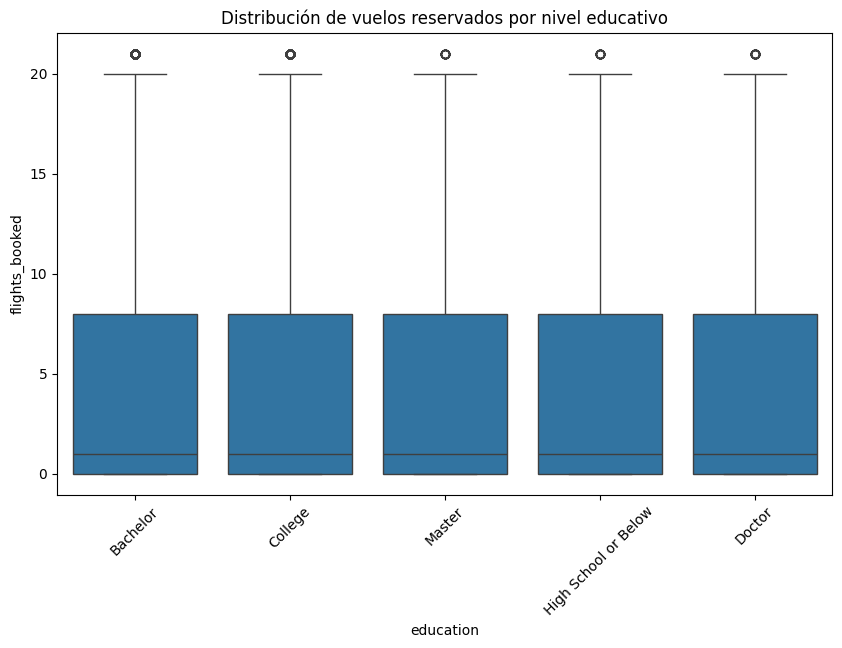

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_filtrado,
    x='education',
    y='flights_booked'
)

plt.title('Distribución de vuelos reservados por nivel educativo')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Observación: con el boxplot podemos ver la presencia de outliers altos, quiere decir que hay pocos clientes con reservas de vuelos altas